<a href="https://colab.research.google.com/github/redgrave17/finalproject/blob/claude%2Faffectionate-allen-8eoaxi/gb_demand_forecast_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Forecasting Great Britain's daily peak electricity demand

In [1]:
import glob
import json
import os
import time
import warnings

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_breusch_godfrey, het_breuschpagan
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss

pd.set_option("display.width", 140)

IN_NOTEBOOK = "__file__" not in globals()
if not IN_NOTEBOOK:
    matplotlib.use("Agg")          # headless when run as a script

HERE = os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else "."
# This resolves to the current working directory.
FIGDIR = os.path.join(HERE, "figures")
RESDIR = os.path.join(HERE, "results")
os.makedirs(FIGDIR, exist_ok=True)
os.makedirs(RESDIR, exist_ok=True)

# Report house style.
BLUE, LIGHTBLUE, ORANGE, RED, GREY = "#2166ac", "#67a9cf", "#ef8a62", "#b2182b", "grey"

VALUES = {}          # every scalar the report quotes in prose
def record(**kw):
    VALUES.update(kw)


def finish(fig, name):
    """Save a figure at the name the report embeds, and show it in a notebook."""
    fig.savefig(os.path.join(FIGDIR, name), dpi=150, bbox_inches="tight")
    if IN_NOTEBOOK:
        plt.show()
    else:
        plt.close(fig)

## 1. Read, prepare, and split the data

In [2]:
LOCAL_CSV = os.path.join(HERE, "data", "historic_demand_2009_2024.csv.gz")

if os.path.exists(LOCAL_CSV):
    CSV = LOCAL_CSV
    print("Using the in-repo dataset:", os.path.basename(CSV))
else:
    try:
        import kagglehub
    except ImportError:
        import subprocess
        import sys
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "kagglehub"], check=True)
        import kagglehub
    path = kagglehub.dataset_download("albertovidalrod/electricity-consumption-uk-20092022")
    csvs = sorted(glob.glob(os.path.join(path, "**", "*.csv"), recursive=True))
    CSV = next((c for c in csvs if "2024" in os.path.basename(c)),
               next((c for c in csvs if "historic_demand" in os.path.basename(c).lower()), csvs[0]))
    print("Using the Kaggle download:", os.path.basename(CSV))

raw = pd.read_csv(CSV)

# groupby().max() would conceal an incomplete day, so completeness is checked
# rather than assumed. Nothing here modifies the data.
for col in ("nd", "embedded_solar_capacity", "is_holiday"):
    assert raw[col].notna().all(), f"missing values in {col}, which the analysis uses"
assert not raw.duplicated(["settlement_date", "settlement_period"]).any(), \
    "duplicate settlement_date/settlement_period rows"

# The header and date format change partway through the record, so parse ISO first
# and retry the stragglers day-first.
d = pd.to_datetime(raw["settlement_date"], errors="coerce")
miss = d.isna()
if miss.any():
    d.loc[miss] = pd.to_datetime(raw.loc[miss, "settlement_date"], dayfirst=True, errors="coerce")
raw["date"] = d.dt.normalize()

g = raw.groupby("date")
day = pd.DataFrame({
    "peak_gw":      g["nd"].max() / 1000,                       # daily maximum National Demand, GW
    "solar_cap_gw": g["embedded_solar_capacity"].max() / 1000,  # GW
    "is_holiday":   g["is_holiday"].max().astype(bool),         # the dataset's own flag
}).reset_index().sort_values("date").reset_index(drop=True)

t0 = day["date"].min()
day["t_days"] = (day["date"] - t0).dt.days.astype(float)
day["trend"] = day["t_days"] / 365.2425                         # years since the first day
WDAYS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]       # Monday is the reference level
day["wday"] = pd.Categorical([WDAYS[x] for x in day["date"].dt.weekday], categories=WDAYS)
day["hol"] = day["is_holiday"].astype(int)

# Annual Fourier pairs on continuous elapsed time, so the phase does not reset each January.
for k in range(1, 7):
    day[f"s{k}"] = np.sin(2 * np.pi * k * day["t_days"] / 365.2425)
    day[f"c{k}"] = np.cos(2 * np.pi * k * day["t_days"] / 365.2425)

# Daily coverage must be continuous: an ARIMA on daily data treats consecutive
# rows as consecutive days, so a silent calendar gap would become a shorter lag.
_cal = pd.date_range(day["date"].min(), day["date"].max(), freq="D")
_missing_dates = _cal.difference(pd.DatetimeIndex(day["date"]))
assert len(_missing_dates) == 0, f"missing calendar dates: {list(_missing_dates)}"

# 46- and 50-period days are the daylight-saving transitions and are expected.
_periods = raw.groupby("date").size().value_counts()
_p46, _p48, _p50 = (int(_periods.get(n, 0)) for n in (46, 48, 50))
assert _p46 + _p48 + _p50 == len(day), \
    f"unexpected settlement-period counts: {dict(_periods)}"

quality = pd.DataFrame([
    ("Half-hourly rows", len(raw)),
    ("Calendar days", len(_cal)),
    ("Observed days", int(day["date"].nunique())),
    ("Missing calendar dates", len(_missing_dates)),
    ("Duplicate date/period rows", 0),
    ("Days with 46 periods (spring DST)", _p46),
    ("Days with 48 periods", _p48),
    ("Days with 50 periods (autumn DST)", _p50),
    ("Missing nd / solar / holiday values", 0),
], columns=["Check", "Value"])
quality.to_csv(os.path.join(RESDIR, "data_quality_summary.csv"), index=False)
print("\n[data quality]")
print(quality.to_string(index=False))

train = day[day["date"] <= "2023-12-31"].copy()
test = day[day["date"] >= "2024-01-01"].copy()

record(n_periods_46=_p46, n_periods_48=_p48, n_periods_50=_p50,
       n_missing_dates=len(_missing_dates), n_halfhours=len(raw),
       n_days=len(day), n_train=len(train), n_test=len(test),
       n_holidays=int(day["hol"].sum()),
       date_min=day["date"].min().strftime("%-d %B %Y"),
       date_max=day["date"].max().strftime("%-d %B %Y"),
       year_min=int(day["date"].min().year), year_max=int(day["date"].max().year))
print(f"day: {len(day)} rows | train: {len(train)} | test: {len(test)} | "
      f"holidays: {int(day['hol'].sum())}")

Using Colab cache for faster access to the 'electricity-consumption-uk-20092022' dataset.
Using the Kaggle download: historic_demand_2009_2024.csv

[data quality]
                              Check  Value
                   Half-hourly rows 279264
                      Calendar days   5818
                      Observed days   5818
             Missing calendar dates      0
         Duplicate date/period rows      0
  Days with 46 periods (spring DST)     16
               Days with 48 periods   5786
  Days with 50 periods (autumn DST)     16
Missing nd / solar / holiday values      0
day: 5818 rows | train: 5478 | test: 340 | holidays: 131


## 2. Fourier order chosen on the training data only (elbow rule)
Pick the largest $K$ before the next harmonic adds less than 0.002 to adjusted $R^2$. AICc is reported
for context but is **not** used to choose $K$ (with ~5,500 training days it keeps falling past
practically negligible gains). AICc uses R's `lm` definition so the values match the report.

In [3]:
def _ols_fourier(K, data):
    # Calendar-only, matching the forecasting design matrix exactly. Embedded solar
    # is deliberately absent: it is excluded at forecast time, so selecting K in a
    # model that contains it would tune the order on a specification never deployed.
    cols = ["trend"] + [f"{p}{k}" for k in range(1, K + 1) for p in ("s", "c")]
    X = pd.get_dummies(data["wday"], drop_first=True).astype(float)   # Tue..Sun
    Xd = pd.concat([data[cols].reset_index(drop=True), X.reset_index(drop=True)], axis=1)
    Xd = sm.add_constant(Xd)
    Xd["is_holiday"] = data["is_holiday"].astype(float).values
    return sm.OLS(data["peak_gw"].values, Xd.astype(float)).fit()


def _aicc(rss, n, ncoef):
    ll = -0.5 * n * (np.log(2 * np.pi) + 1 + np.log(rss / n))
    k = ncoef + 1                                                     # + sigma
    return (-2 * ll + 2 * k) + 2 * k * (k + 1) / (n - k - 1)


rows = []
for K in range(1, 7):
    r = _ols_fourier(K, train)
    rows.append({"K": K, "adj_R2": r.rsquared_adj, "AICc": _aicc(r.ssr, int(r.nobs), len(r.params))})
k_tab = pd.DataFrame(rows)
k_tab["delta"] = k_tab["adj_R2"].diff()
first_small = k_tab.index[k_tab["delta"] < 0.002]
K_final = int(k_tab.loc[first_small[0], "K"] - 1) if len(first_small) else 6

table2 = pd.DataFrame({
    "K": k_tab["K"],
    "Adj. R2": k_tab["adj_R2"].round(4),
    "Delta adj. R2": k_tab["delta"].round(4),
    "AICc": k_tab["AICc"].round(2),
})
table2.to_csv(os.path.join(RESDIR, "table2_fourier.csv"), index=False)
# Rounded exactly as Table 2 rounds it, so the prose and the table cannot disagree
# on the same number (numpy and Python round a trailing 5 in opposite directions).
record(K_final=K_final,
       elbow_delta_at_K=float(np.round(k_tab.loc[K_final - 1, "delta"], 4))
       if K_final > 1 else None,
       elbow_delta_next=float(np.round(k_tab.loc[K_final, "delta"], 4)))
print(table2.to_string(index=False), "\nK_final =", K_final)

 K  Adj. R2  Delta adj. R2     AICc
 1   0.9154            NaN 23793.08
 2   0.9182         0.0028 23613.17
 3   0.9279         0.0098 22920.25
 4   0.9296         0.0017 22790.69
 5   0.9304         0.0008 22728.68
 6   0.9323         0.0018 22583.52 
K_final = 3


## 3. Descriptive full-sample model and robust inference

Fitted on the whole sample to report effect sizes only. It neither chooses K nor
forecasts. Standard errors are Newey-West HAC (Bartlett kernel, bandwidth 14, no
small-sample correction). Day-of-week is tested as one omnibus family.

In [4]:
desc = smf.ols(
    "peak_gw ~ trend + s1+c1+s2+c2+s3+c3 + C(wday) + is_holiday + solar_cap_gw",
    data=day
).fit(cov_type="HAC", cov_kwds={"maxlags": 14, "use_correction": False})

lab = {"trend": "Trend, per year",
       "s1": "sin(1x annual)", "c1": "cos(1x annual)", "s2": "sin(2x annual)",
       "c2": "cos(2x annual)", "s3": "sin(3x annual)", "c3": "cos(3x annual)",
       "C(wday)[T.Tue]": "Tuesday vs Monday", "C(wday)[T.Wed]": "Wednesday vs Monday",
       "C(wday)[T.Thu]": "Thursday vs Monday", "C(wday)[T.Fri]": "Friday vs Monday",
       "C(wday)[T.Sat]": "Saturday vs Monday", "C(wday)[T.Sun]": "Sunday vs Monday",
       "is_holiday[T.True]": "Public holiday",
       "solar_cap_gw": "Embedded solar capacity, per GW"}

eff = []
for term, name in lab.items():
    b, se, p = desc.params[term], desc.bse[term], desc.pvalues[term]
    eff.append({"Effect": name, "Effect (GW)": round(b, 2),
                "95% CI (GW)": f"{b - 1.96 * se:.2f} to {b + 1.96 * se:.2f}",
                "p": "<0.001" if p < 0.001 else f"{p:.3f}"})
table3 = pd.DataFrame(eff)
table3.to_csv(os.path.join(RESDIR, "table3_effects.csv"), index=False)

# Omnibus F for the whole day-of-week family (classical nested comparison).
red = smf.ols("peak_gw ~ trend + s1+c1+s2+c2+s3+c3 + is_holiday + solar_cap_gw", data=day).fit()
df_diff = int(desc.df_model - red.df_model)
F = ((red.ssr - desc.ssr) / df_diff) / (desc.ssr / desc.df_resid)

# Pre-declared sensitivity only: a quadratic trend. Not the forecasting specification.
quad = smf.ols("peak_gw ~ trend + I(trend**2) + s1+c1+s2+c2+s3+c3 + C(wday) + is_holiday + solar_cap_gw",
               data=day).fit()

tb = desc.params["trend"]
tse = desc.bse["trend"]
record(adj_r2=round(float(desc.rsquared_adj), 4),
       trend_gw=round(float(tb), 2),
       trend_lo=abs(round(float(tb + 1.96 * tse), 2)), trend_hi=abs(round(float(tb - 1.96 * tse), 2)),
       holiday_gw=abs(round(float(desc.params["is_holiday[T.True]"]), 2)),
       saturday_gw=abs(round(float(desc.params["C(wday)[T.Sat]"]), 2)),
       sunday_gw=abs(round(float(desc.params["C(wday)[T.Sun]"]), 2)),
       solar_gw=round(float(desc.params["solar_cap_gw"]), 2),
       solar_p=round(float(desc.pvalues["solar_cap_gw"]), 3),
       solar_corr=round(float(day["solar_cap_gw"].corr(day["trend"])), 2),
       F_stat=int(round(F)), F_df1=df_diff, F_df2=int(desc.df_resid),
       aic_linear=int(round(desc.aic)), aic_quad=int(round(quad.aic)),
       curvature=round(float(quad.params["I(trend ** 2)"]), 3))
print("Adjusted R^2 =", round(desc.rsquared_adj, 4))
print(table3.to_string(index=False))
print(f"Day-of-week omnibus F({df_diff}, {int(desc.df_resid)}) = {F:.0f}")
print(f"Quadratic sensitivity: AIC {desc.aic:.0f} -> {quad.aic:.0f}, "
      f"curvature {quad.params['I(trend ** 2)']:.4f}")

Adjusted R^2 = 0.9294
                         Effect  Effect (GW)    95% CI (GW)      p
                Trend, per year        -0.76 -0.87 to -0.65 <0.001
                 sin(1x annual)         0.43   0.24 to 0.62 <0.001
                 cos(1x annual)         7.49   7.29 to 7.69 <0.001
                 sin(2x annual)         0.11  -0.06 to 0.29  0.208
                 cos(2x annual)         0.52   0.30 to 0.73 <0.001
                 sin(3x annual)         0.07  -0.11 to 0.26  0.442
                 cos(3x annual)        -1.00 -1.20 to -0.81 <0.001
              Tuesday vs Monday        -0.09  -0.20 to 0.02  0.100
            Wednesday vs Monday        -0.18 -0.30 to -0.06  0.003
             Thursday vs Monday        -0.38 -0.51 to -0.26 <0.001
               Friday vs Monday        -1.42 -1.56 to -1.29 <0.001
             Saturday vs Monday        -5.03 -5.18 to -4.89 <0.001
               Sunday vs Monday        -4.68 -4.85 to -4.52 <0.001
                 Public holiday        -

## 4. Residual diagnostics and stationarity tests

In [5]:
res = desc.resid.values
n = len(res)
bg = acorr_breusch_godfrey(desc, nlags=7)
bp = het_breuschpagan(res, desc.model.exog)
adf = adfuller(res, maxlag=int((n - 1) ** (1 / 3)), regression="ct", autolag=None)
kp = kpss(res, regression="c", nlags="auto")

table4 = pd.DataFrame({
    "Test": ["Breusch-Godfrey (7 lags)", "Breusch-Pagan", "Augmented Dickey-Fuller", "KPSS (level)"],
    "Statistic": [round(bg[0], 2), round(bp[0], 2), round(adf[0], 2), round(kp[0], 3)],
    "p": ["<0.001", "<0.001", "<0.01", f"{kp[1]:.3f}"],
})
table4.to_csv(os.path.join(RESDIR, "table4_diagnostics.csv"), index=False)
from statsmodels.tsa.stattools import acf as _acf
acf30 = _acf(res, nlags=30, fft=False)
record(bg_stat=round(float(bg[0]), 2), bp_stat=round(float(bp[0]), 2),
       adf_stat=round(float(adf[0]), 2),
       kpss_stat=round(float(kp[0]), 3), kpss_p=round(float(kp[1]), 3),
       acf_lag1=round(float(acf30[1]), 2),
       acf_lag7=round(float(acf30[7]), 2), acf_lag14=round(float(acf30[14]), 2))
print(table4.to_string(index=False))
print(f"residual ACF: lag1={acf30[1]:.2f} lag7={acf30[7]:.2f} lag14={acf30[14]:.2f}")

                    Test  Statistic      p
Breusch-Godfrey (7 lags)   3402.140 <0.001
           Breusch-Pagan    589.790 <0.001
 Augmented Dickey-Fuller    -13.160  <0.01
            KPSS (level)      0.249  0.100
residual ACF: lag1=0.73 lag7=0.44 lag14=0.24


/tmp/ipykernel_3312/1564009281.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kp = kpss(res, regression="c", nlags="auto")


## 5. Leakage-free forecasting machinery

Calendar regressors only: trend, the K harmonics, day-of-week and the holiday flag.
Embedded solar is deliberately excluded. The design matrix has a fixed column order so
history and future always line up. MASE is scaled by the in-sample MAE of a 7-day
seasonal naive on the history available at that origin.

In [6]:
HARM = [f"{p}{k}" for k in range(1, K_final + 1) for p in ("s", "c")]
WD = ["Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]              # Monday reference dropped
MODELS = ["Harmonic regression", "Dynamic regression", "Weekly seasonal naive", "364-day seasonal naive"]
ORDER = (3, 0, 1)
FIT_AUDIT = []          # one record per ARIMA fit, written to results/model_fit_audit.csv


def make_xreg(df):
    parts = [df["trend"].values.reshape(-1, 1), df[HARM].values]
    dm = pd.get_dummies(df["wday"]).reindex(columns=WDAYS, fill_value=0)
    parts.append(dm[WD].values.astype(float))
    parts.append(df["hol"].values.reshape(-1, 1).astype(float))
    return np.column_stack(parts).astype(float)


def mase_scale(y, m=7):
    return np.mean(np.abs(y[m:] - y[:-m]))


def fit_origin(history, future, order=ORDER):
    """Forecast every model from one origin, and audit the ARIMA fit.

    If the ARIMA fit raises, the dynamic forecast is left missing and the failure is
    recorded. It is never replaced by the harmonic forecast: doing so would report an
    OLS path under the dynamic-regression label and silently flatter that model.
    """
    yh = history["peak_gw"].values
    Xh, Xf = make_xreg(history), make_xreg(future)
    H = len(future)
    ols = sm.OLS(yh, sm.add_constant(Xh)).fit()                       # plain harmonic regression
    plm = np.asarray(ols.predict(sm.add_constant(Xf, has_constant="add")))

    audit = {"origin": history["date"].max(), "n_history": len(history), "order": str(order),
             "converged": False, "iterations": np.nan, "warn_count": 0,
             "warning_types": "", "error": "", "forecast_missing": False}
    try:                                                              # regression with ARIMA errors
        with warnings.catch_warnings(record=True) as ws:
            warnings.simplefilter("always")
            am = ARIMA(yh, exog=Xh, order=order, trend="c").fit()
        audit["converged"] = bool(am.mle_retvals.get("converged", False))
        audit["iterations"] = am.mle_retvals.get("iterations", np.nan)
        audit["warn_count"] = len(ws)
        audit["warning_types"] = "; ".join(sorted({type(w.message).__name__ for w in ws}))
        dyn = np.asarray(am.get_forecast(steps=H, exog=Xf).predicted_mean)
    except Exception as e:
        audit["error"] = repr(e)
        audit["forecast_missing"] = True
        dyn = np.full(H, np.nan)                                      # never substitute plm
    FIT_AUDIT.append(audit)
    return pd.DataFrame({
        "date": future["date"].values, "lead": np.arange(1, H + 1),
        "actual": future["peak_gw"].values,
        "Harmonic regression": plm, "Dynamic regression": dyn,
        "Weekly seasonal naive": np.resize(yh[-7:], H),               # repeat the last week
        "364-day seasonal naive": np.resize(yh[-364:], H),            # same weekday last year
        "mase_denom": mase_scale(yh),
    })


def accuracy_by(frame, levels, horizon_fn):
    long = frame.melt(id_vars=["date", "lead", "actual", "mase_denom"],
                      value_vars=MODELS, var_name="Model", value_name="pred")
    n_before = len(long)
    long = long.dropna(subset=["pred"])
    if len(long) != n_before:                  # a fit failed, partial coverage is not averaged silently
        raise RuntimeError(f"{n_before - len(long)} forecasts missing; see model_fit_audit.csv")
    long["Horizon"] = horizon_fn(long["lead"].values)
    long["ae"] = (long.actual - long.pred).abs()
    long["se"] = (long.actual - long.pred) ** 2
    long["scaled"] = long["ae"] / long["mase_denom"]
    out = (long.groupby(["Horizon", "Model"], observed=True)
               .agg(MAE=("ae", "mean"), RMSE=("se", "mean"), MASE=("scaled", "mean")).reset_index())
    out["RMSE"] = np.sqrt(out["RMSE"])
    for c in ["MAE", "RMSE", "MASE"]:
        out[c] = out[c].round(2)
    out["Horizon"] = pd.Categorical(out["Horizon"], categories=levels, ordered=True)
    return out.sort_values(["Horizon", "MAE"]).reset_index(drop=True)

## 6. ARIMA error order

A full AICc grid over (p,0,q) with p,q <= 3 on the training data. The grid minimum is
reported honestly. The order actually used is locked at ARIMA(3,0,1) and re-estimated,
not re-selected, at every origin. Section 4.4 of the report explains that choice.

In [7]:
def order_grid(y, X, pmax=3, qmax=3):
    out = []
    for p in range(pmax + 1):
        for q in range(qmax + 1):
            try:
                with warnings.catch_warnings(record=True) as ws:
                    warnings.simplefilter("always")
                    r = ARIMA(y, exog=X, order=(p, 0, q), trend="c").fit()
                k, nn = len(r.params), r.nobs
                out.append({"order": f"({p},0,{q})",
                            "AICc": round(r.aic + 2 * k * (k + 1) / (nn - k - 1), 2),
                            "converged": bool(r.mle_retvals.get("converged", False)),
                            "iterations": r.mle_retvals.get("iterations"),
                            "warnings": "; ".join(sorted({type(w.message).__name__ for w in ws})),
                            "error": ""})
            except Exception as e:
                out.append({"order": f"({p},0,{q})", "AICc": np.nan, "converged": False,
                            "iterations": np.nan, "warnings": "", "error": repr(e)})
    return pd.DataFrame(out).sort_values("AICc").reset_index(drop=True)


t_grid = time.time()
grid = order_grid(train["peak_gw"].values, make_xreg(train))
grid.to_csv(os.path.join(RESDIR, "arima_grid.csv"), index=False)
used = grid.loc[grid["order"] == "(3,0,1)"].iloc[0]
best = grid.iloc[0]
# The AICc minimum is worth little if the optimiser never settled, so track the best
# fit that did converge separately.
conv = grid[grid["converged"]].reset_index(drop=True)
best_conv = conv.iloc[0]
record(arima_order="(3,0,1)",
       arima_grid_best=str(best["order"]), arima_grid_best_aicc=float(best["AICc"]),
       arima_grid_best_converged=bool(best["converged"]),
       arima_used_aicc=float(used["AICc"]),
       arima_used_converged=bool(used["converged"]),
       arima_aicc_gap=int(round(float(used["AICc"]) - float(best["AICc"]))),
       arima_used_rank=int(grid.index[grid["order"] == "(3,0,1)"][0]) + 1,
       arima_best_converged_order=str(best_conv["order"]),
       arima_best_converged_aicc=float(best_conv["AICc"]),
       arima_converged_gap=round(float(best_conv["AICc"]) - float(used["AICc"]), 2),
       arima_n_converged=int(grid["converged"].sum()), arima_n_fits=int(len(grid)))
print(f"grid in {time.time() - t_grid:.0f}s")
print(grid.head(6).to_string(index=False))

grid in 411s
  order     AICc  converged  iterations                        warnings error
(3,0,3) 17680.88      False          50              ConvergenceWarning      
(3,0,1) 17935.59      False          50              ConvergenceWarning      
(2,0,2) 17935.88      False          50              ConvergenceWarning      
(1,0,3) 17936.01      False          50              ConvergenceWarning      
(3,0,2) 17938.53      False          50 ConvergenceWarning; UserWarning      
(2,0,3) 17940.15      False          50              ConvergenceWarning      


## 7. Rolling-origin evaluation

Weekly origins across 2024, forecasting up to 30 days. Every model is refitted from the
history available at that origin, so no later-observed value is ever used. The 30-day
windows overlap, so these are an operational accuracy summary, not independent tests.

In [8]:
Hmax = 30
maxd = day["date"].max()
origins = pd.date_range("2023-12-31", maxd - pd.Timedelta(days=Hmax), freq="7D")
print(f"{len(origins)} rolling origins")

parts = []
t_roll = time.time()
for i, o in enumerate(origins, 1):
    hist = day[day["date"] <= o]
    fut = day[(day["date"] > o) & (day["date"] <= o + pd.Timedelta(days=Hmax))].head(Hmax)
    if len(fut) == 0:
        continue
    fo = fit_origin(hist, fut)
    fo["origin"] = o
    parts.append(fo)
    if i % 10 == 0:
        print(f"  origin {i}/{len(origins)} ({time.time() - t_roll:.0f}s)", flush=True)
roll = pd.concat(parts, ignore_index=True)

# Origin fit audit
fit_audit = pd.DataFrame(FIT_AUDIT)
fit_audit.to_csv(os.path.join(RESDIR, "model_fit_audit.csv"), index=False)
n_conv = int(fit_audit["converged"].sum())
n_fail = int(fit_audit["forecast_missing"].sum())
record(n_origins_converged=n_conv, n_origin_fits=len(fit_audit),
       n_forecast_failures=n_fail,
       origin_iterations_median=float(fit_audit["iterations"].median()))
print(f"\n[fit audit] {n_conv}/{len(fit_audit)} origins converged, "
      f"{n_fail} forecast failures, median iterations "
      f"{fit_audit['iterations'].median():.0f}")
print(fit_audit[["converged", "warn_count", "forecast_missing"]].sum().to_string())

roll_h = lambda lead: np.where(lead == 1, "1 day", np.where(lead <= 7, "2-7 days", "8-30 days"))
table5 = accuracy_by(roll, ["1 day", "2-7 days", "8-30 days"], roll_h)
table5.to_csv(os.path.join(RESDIR, "table5_rolling.csv"), index=False)

r1 = table5[table5["Horizon"] == "1 day"].reset_index(drop=True)
record(n_origins=len(origins), Hmax=Hmax,
       dyn_1d_mase=float(r1.loc[r1["Model"] == "Dynamic regression", "MASE"].iloc[0]),
       best_bench_1d_mase=float(r1[r1["Model"] != "Dynamic regression"]["MASE"].min()),
       best_bench_1d=str(r1[r1["Model"] != "Dynamic regression"].iloc[0]["Model"]))
print(table5.to_string(index=False))

45 rolling origins
  origin 10/45 (323s)
  origin 20/45 (663s)
  origin 30/45 (998s)
  origin 40/45 (1340s)

[fit audit] 0/45 origins converged, 0 forecast failures, median iterations 50
converged            0
warn_count          46
forecast_missing     0
  Horizon                  Model  MAE  RMSE  MASE
    1 day     Dynamic regression 1.17  1.41  0.69
    1 day 364-day seasonal naive 1.50  2.02  0.88
    1 day    Harmonic regression 1.59  2.03  0.93
    1 day  Weekly seasonal naive 2.02  2.78  1.19
 2-7 days     Dynamic regression 1.30  1.66  0.77
 2-7 days 364-day seasonal naive 1.35  1.81  0.80
 2-7 days    Harmonic regression 1.63  1.99  0.96
 2-7 days  Weekly seasonal naive 1.68  2.18  0.99
8-30 days 364-day seasonal naive 1.34  1.81  0.79
8-30 days     Dynamic regression 1.47  1.87  0.87
8-30 days    Harmonic regression 1.59  1.98  0.94
8-30 days  Weekly seasonal naive 2.65  3.42  1.56


## 8. Secondary fixed-origin accuracy (2024 holdout)
A single origin at 31 December 2023, retained as a stress test.

In [9]:
fixed_h = lambda lead: pd.cut(lead, [0, 7, 30, np.inf], labels=["1-7 days", "8-30 days", "31+ days"])
fx = fit_origin(train, test)
table6 = accuracy_by(fx, ["1-7 days", "8-30 days", "31+ days"], fixed_h)
table6.to_csv(os.path.join(RESDIR, "table6_fixed.csv"), index=False)
print(table6.to_string(index=False))

  Horizon                  Model  MAE  RMSE  MASE
 1-7 days    Harmonic regression 1.82  2.34  1.08
 1-7 days     Dynamic regression 2.49  3.29  1.47
 1-7 days 364-day seasonal naive 3.08  3.37  1.83
 1-7 days  Weekly seasonal naive 6.24  6.38  3.70
8-30 days    Harmonic regression 2.22  2.53  1.32
8-30 days     Dynamic regression 2.76  3.19  1.63
8-30 days 364-day seasonal naive 2.95  3.44  1.75
8-30 days  Weekly seasonal naive 8.18  8.85  4.85
 31+ days 364-day seasonal naive 1.35  1.84  0.80
 31+ days     Dynamic regression 1.63  2.01  0.97
 31+ days    Harmonic regression 1.65  2.04  0.98
 31+ days  Weekly seasonal naive 4.57  5.38  2.71


## 9. Figures for the report
Fig 1 fitted curve · Fig 2 residual ACF/PACF · Fig 3 STL · Fig 4 rolling MAE by horizon · Fig 5 a
representative forecast window.

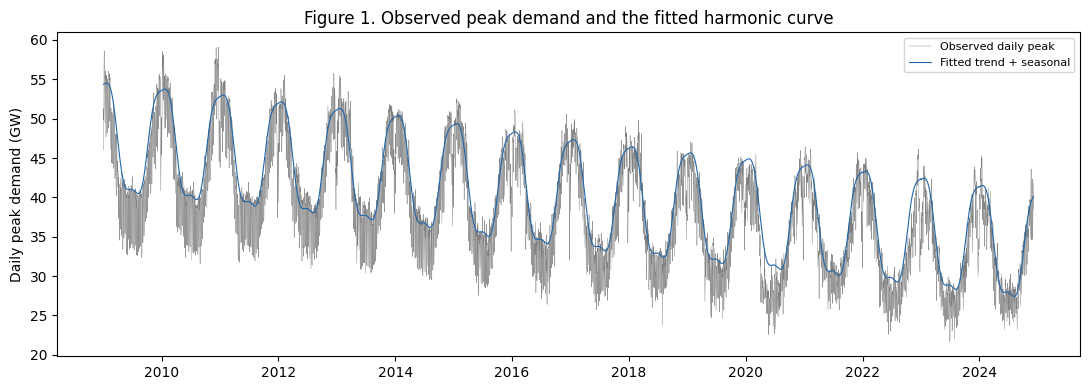

In [10]:
# Figure 1: observed peak demand against the fitted harmonic curve (Monday, non-holiday).
ref = day.copy()
ref["wday"] = pd.Categorical(["Mon"] * len(ref), categories=WDAYS)
ref["is_holiday"] = False
day["fit_ref"] = desc.predict(ref)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(day["date"], day["peak_gw"], color=GREY, lw=0.3, label="Observed daily peak")
ax.plot(day["date"], day["fit_ref"], color=BLUE, lw=0.8, label="Fitted trend + seasonal")
ax.set_ylabel("Daily peak demand (GW)")
ax.set_xlabel("")
ax.set_title("Figure 1. Observed peak demand and the fitted harmonic curve")
ax.legend(fontsize=8, loc="upper right")
fig.tight_layout()
finish(fig, "fig1-fitted.png")

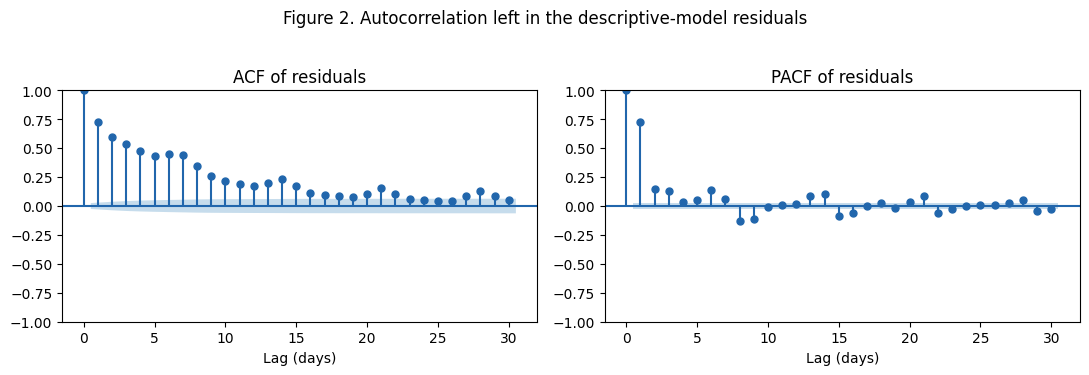

In [11]:
# Figure 2: residual ACF and PACF: the evidence for an ARIMA error structure.
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
plot_acf(res, lags=30, ax=ax[0], color=BLUE, vlines_kwargs={"colors": BLUE})
ax[0].set_title("ACF of residuals")
plot_pacf(res, lags=30, ax=ax[1], method="ywm", color=BLUE, vlines_kwargs={"colors": BLUE})
ax[1].set_title("PACF of residuals")
for a in ax:
    a.set_xlabel("Lag (days)")
fig.suptitle("Figure 2. Autocorrelation left in the descriptive-model residuals", y=1.03)
fig.tight_layout()
finish(fig, "fig2-acf-pacf.png")

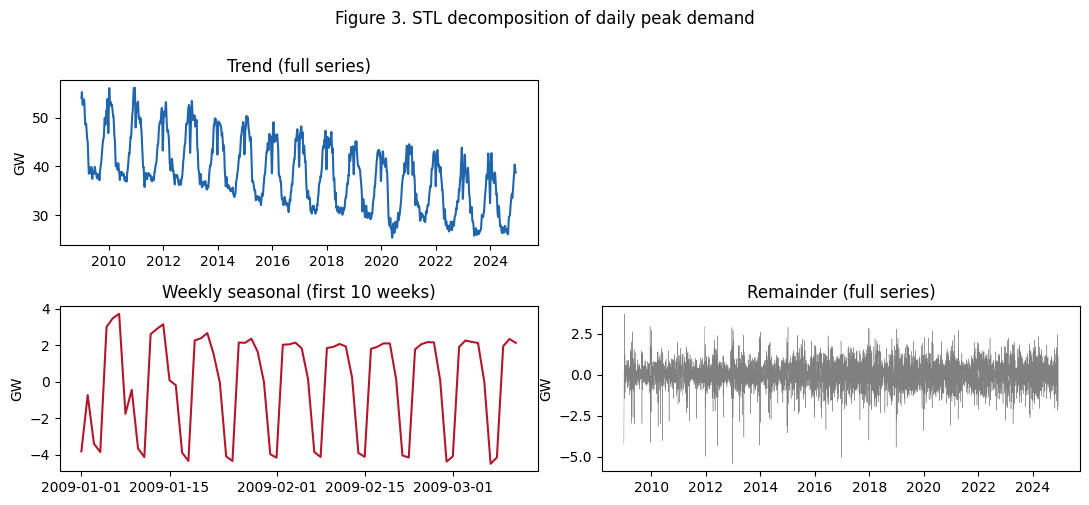

In [12]:
# Figure 3: STL decomposition at the weekly period.
stl = STL(day["peak_gw"].values, period=7, seasonal=7, robust=False).fit()
fig, ax = plt.subplots(2, 2, figsize=(11, 5))
ax[0, 0].plot(day["date"], stl.trend, color=BLUE)
ax[0, 0].set_title("Trend (full series)")
ax[0, 1].axis("off")
ax[1, 0].plot(day["date"][:70], stl.seasonal[:70], color=RED)
ax[1, 0].set_title("Weekly seasonal (first 10 weeks)")
ax[1, 1].plot(day["date"], stl.resid, color=GREY, lw=0.3)
ax[1, 1].set_title("Remainder (full series)")
for a in ax.ravel():
    if a.has_data():
        a.set_ylabel("GW")
fig.suptitle("Figure 3. STL decomposition of daily peak demand", y=1.00)
fig.tight_layout()
finish(fig, "fig3-stl.png")

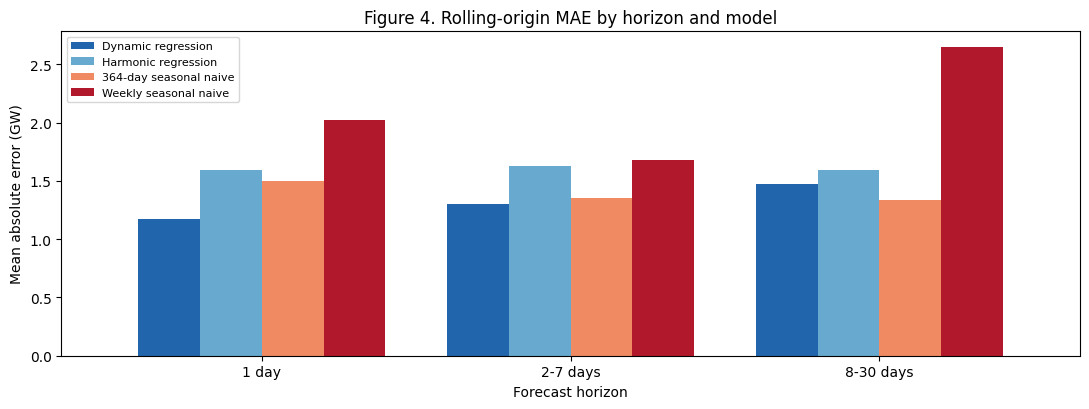

In [13]:
# Figure 4: rolling-origin MAE by horizon and model.
order_h = ["1 day", "2-7 days", "8-30 days"]
order_m = ["Dynamic regression", "Harmonic regression", "364-day seasonal naive", "Weekly seasonal naive"]
colors = {"Dynamic regression": BLUE, "Harmonic regression": LIGHTBLUE,
          "364-day seasonal naive": ORANGE, "Weekly seasonal naive": RED}
piv = table5.pivot(index="Horizon", columns="Model", values="MAE").reindex(order_h)[order_m]

fig, ax = plt.subplots(figsize=(11, 4.2))
piv.plot(kind="bar", ax=ax, color=[colors[m] for m in order_m], width=0.8)
ax.set_ylabel("Mean absolute error (GW)")
ax.set_xlabel("Forecast horizon")
ax.set_title("Figure 4. Rolling-origin MAE by horizon and model")
ax.tick_params(axis="x", rotation=0)
ax.legend(loc="upper left", fontsize=8)
fig.tight_layout()
finish(fig, "fig4-rolling-mae.png")

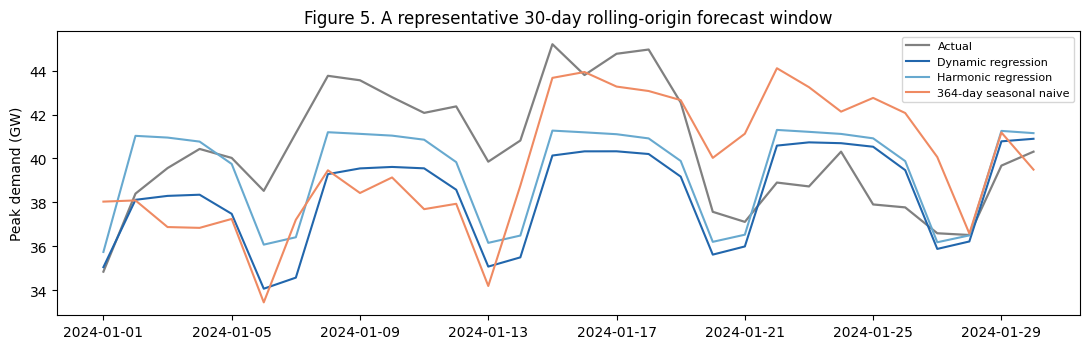

figures written to ./figures


In [14]:
# Figure 5: a representative 30-day rolling-origin window (the first origin).
w = roll[roll["origin"] == roll["origin"].min()]

# The cold-spell miss the report reads off this window, exported rather than eyeballed.
_pk = w.loc[w["actual"].idxmax()]
record(win_peak_gw=round(float(_pk["actual"]), 1),
       win_peak_date=pd.Timestamp(_pk["date"]).strftime("%-d %B %Y"),
       win_peak_miss_dyn=round(float(_pk["actual"] - _pk["Dynamic regression"]), 1),
       win_peak_miss_harm=round(float(_pk["actual"] - _pk["Harmonic regression"]), 1))
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(w["date"], w["actual"], color=GREY, lw=1.6, label="Actual")
ax.plot(w["date"], w["Dynamic regression"], color=BLUE, label="Dynamic regression")
ax.plot(w["date"], w["Harmonic regression"], color=LIGHTBLUE, label="Harmonic regression")
ax.plot(w["date"], w["364-day seasonal naive"], color=ORANGE, label="364-day seasonal naive")
ax.set_ylabel("Peak demand (GW)")
ax.set_title("Figure 5. A representative 30-day rolling-origin forecast window")
ax.legend(fontsize=8)
fig.tight_layout()
finish(fig, "fig5-forecast-window.png")

print("figures written to", FIGDIR)